# **Lab 6 - Variance reduction and rare events in Monte Carlo**

## Variance reduction

We saw that classical Monte Carlo estimation is based on the idea that if $\mathbf{X}_1,\dots,\mathbf{X}_N$ is an i.i.d. sample with $\mathbf{X}_i\sim\mathbf{X}$ and $\Psi:\mathbb{R}^{d}\to\mathbb{R}$, then

$$\left|\mathbb{E}\left[\Psi(\mathbf{X})\right]-\frac{1}{N}\sum_{i=1}^{N}\Psi(\mathbf{X}_i)\right|\le z_{\alpha/2}\sqrt{\frac{\text{Var}\;\Psi(\mathbf{X})}{N}}$$

with (approximately) probability $1-\alpha$.
</br></br>
In particular, if we let $Y:=\Psi(\mathbf{X})$ and $Y_i:=\Psi(\mathbf{X}_i)$, we see that uncertainty (but also the accuracy) of the Monte Carlo estimator $I_N:=N^{-1}\sum_{i=1}^{N} Y_i$ in approximating $I:=\mathbb{E}[Y]$ depends on $\text{Var}(Y)$and $N.$
</br></br>
We saw that Quasi-Monte Carlo methods can help improving the convergence rate with respect to $N$. Now, we would like to focus on the other factor, i.e., on the term related to the *variance*. In this concern, we notice that if $Z$ is any random variable with $\mathbb{E}[Z]=\mathbb{E}[Y]=\mathbb{E}[\Psi(\mathbf{X})]$, then we may as well use $\tilde{I}_N:=N^{-1}\sum_{i=1}^{N} Z_i$ as an alternative estimator. In general, this will always be convenient whenever $\text{Var}(Z)\le\text{Var}(Y)$. Thus, the question is:
</br></br>
$$\text{
Can we construct a new random variable $Z$ that has the same mean as $\Psi(\mathbf{X})$ but a lower variance?}$$

Here, we shall mention three strategies.

### Antithetic variables
Let $\mathbf{X}^*:=2\mathbb{E}[\mathbf{X}]-\mathbf{X}$. The latter is said to be the *antithetic* of $\mathbf{X}$, and it is computed by reflecting $\mathbf{X}$ around the mean.

Let $Z:=\frac{1}{2}\left[\Psi(\mathbf{X})+\Psi(\mathbf{X}^*)\right]$. It can be shown that if

i) $\Psi$ is monotone in all its arguments

ii) the density of $\mathbf{X}$ is symmetric around the mean

then $\mathbb{E}[Z]=\mathbb{E}[\Psi(\mathbf{X})]$ and

$$\text{Var}(Z)\le\frac{1}{4}\text{Var}\;\Psi(\mathbf{X}).$$

In particular, considering that 2 evaluations of $\Psi$ are required to compute $Z$, even if we sample $N/2$ times from $Z$ we expect a variance reduction with respect to sampling $N$ times from $X$.

### Control variates
Let $Q=\Phi(\mathbf{X})$ be a quantity of which the expected value, $\mathbb{E}[Q]$, is known. We call the latter *control variate*. We notice that, for every $c\in\mathbb{R}$, the random variable

$$Z_c:=\Psi(\mathbf{X})+c(Q-\mathbb{E}[Q])$$

has the same mean of $\Psi(\mathbf{X})$, i.e. $\mathbb{E}[Z_c]=\mathbb{E}[\Psi(\mathbf{X})]$. Furthermore, the value

$$c_*:=-\frac{\text{Cov}(\Psi(\mathbf{X}), Q)}{\text{Var}(Q)}$$

minimizes $\text{Var}(Z_c)$. In particular, $\text{Var}(Z_c)<\text{Var}\;\Psi(\mathbf{X})$ whenever $Q$ and $\Psi(\mathbf{X})$ are positively correlated.

### Importance sampling
Let $f$ be the density of $\mathbf{X}$ and let $g$ be another probability distribution over $\mathbb{R}^{d}$. Assume that

$$g(\mathbf{x})>0\;\;\;\forall\mathbf{x}:\;\Psi(\mathbf{x})f(\mathbf{x})>0.$$

Then, if $\tilde{\mathbf{X}}\sim g$ letting

$$Z:=\frac{\Psi(\tilde{\mathbf{X}})f(\tilde{\mathbf{X}})}{g(\tilde{\mathbf{X}})}$$

yields a random variable $Z$ with $\mathbb{E}[Z]=\mathbb{E}[\Psi(\mathbf{X})].$ Furthermore, for suitable choices of $g$, one has $\text{Var}(Z)\le\text{Var}\;\Psi(\mathbf{X}).$

Heuristically, the idea is that, in order to obtain a variance reduction, one should choose $g$ so that the latter gives a higher probability to those regions where $\Psi\cdot f$ is large.

### Numerical experiment

<mark>**Exercise 1**</mark></br>

Let us consider the following diagram, which represents a collection of travelling routes over sea. The random variables $T^{(1)},\dots,T^{(10)}$ denote the travelling times in between locations, whose randomness can be due to weather conditions, etc.

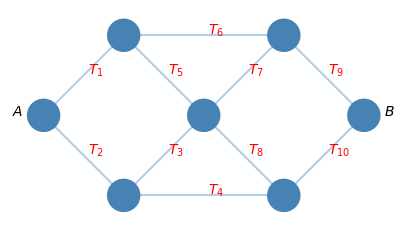

In [1]:
import numpy as np
import matplotlib.pyplot as plt

edges = [(0, 1),
         (0, 2),
         (2, 3),
         (2, 5),
         (1, 3),
         (1, 4),
         (3, 4),
         (3, 5),
         (4, 6),
         (5, 6)]

centers = [(0,0), (1,1), (1, -1), (2, 0), (3,1), (3, -1), (4,0)]

th = np.linspace(0, 2*np.pi, 500)
plt.figure(figsize = (5, 3))
for center in centers:
  x, y = center
  plt.fill(x+0.2*np.cos(th), y+0.2*np.sin(th), color = 'steelblue')
k, h = 0, 0.05
for edge in edges:
  k += 1
  x1, y1 = centers[edge[0]]
  x2, y2 = centers[edge[1]]
  plt.plot([x1, x2], [y1, y2], color = 'steelblue', alpha = 0.4)
  xm, ym = 0.5*(x1+x2), 0.5*(y1+y2)
  plt.text(xm+0.05, ym+0.01, '$T_{%d}$' % k, color = 'red')
plt.text(-0.4, 0, '$A$')
plt.text(4.25, 0, '$B$')
plt.gca().set_aspect("equal")
plt.axis("off")
None

Let $\mathbf{T}:=[T^{(1)},\dots,T^{(10)}]$.
We are interested in the travelling time from $A$ to $B$, defined as the shortest path (in terms of time) from $A$ to $B$. The latter is ultimately computable through a map $\Psi:\mathbb{R}^{10}\to\mathbb{R}$, implemented in the code right below ($\Psi=\textsf{A2B}$).

Our interest is to estimate the expected travelling time from $A$ to $B$, that is,

$$t_{AB}:=\mathbb{E}[\Psi(\mathbf{T})],$$

when $T^{(1)},T^{(2)}\sim\text{Exp}(1/2)$, and $T^{(3)},\dots,T^{(8)}\sim\text{Exp}(2)$ and $T^{(9)},T^{(10)}\sim\text{Exp}(1/5)$ are all independent.

In [44]:
from scipy.sparse.csgraph import shortest_path
def A2B(times):
  T = np.zeros((7, 7))
  for edge, t in zip(edges, times):
    i, j = edge
    T[i,j] = t
  return shortest_path(T)[0, 6]

lambdas = np.array([1.0/2.0, 1.0/2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0/5.0, 1.0/5.0])

**Ex. 1.1** Estimate $t_{AB}$ using classical Monte Carlo with $N=500$ samples.

In doing so, provide also a confidence interval with confidence $\gamma=95\%$.

**<sub>Solution</sub>**

In [85]:
from scipy.stats import norm

def mc_summary(sample, alpha):
    mu = sample.mean()
    std = sample.std(ddof = 1)

    z = norm.ppf(1.0-alpha/2.0)
    uncertainty = z*std/np.sqrt(len(sample))
    print("Estimate\tUncertainty\n"+"-"*27)
    print("%.4f\t\t± %.4f" % (mu, uncertainty))

In [93]:
def mc_sample(N):
  Psi = A2B
  T = np.zeros(N)
  for i in range(N):
    times = np.random.exponential(scale = 1.0/lambdas)
    T[i] = Psi(times)
  return T

N = 500
Tmc = mc_sample(N)

mc_summary(Tmc, alpha = 0.05)

Estimate	Uncertainty
---------------------------
4.0042		± 0.2405


**Ex. 1.2** Estimate $t_{AB}$ using Monte Carlo with antithetic variables. Use a sample of size $N=250$, so that $500$ evaluations of $\Psi$ are computed.

Enrich your estimate with a confidence interval with confidence $\gamma=95\%$. How does the estimate compare to classical Monte Carlo?
</br>
</br>
Warning: the distribution of $T^{(j)}$, and thus $\mathbf{T}$, is NOT symmetric around the mean! Can we fix this issue with a suitable trick?

**<sub>Solution</sub>**

In order to apply the method of antithetic variables, we first use a change of variables such that conditions (i) and (ii) are met. We notice in fact that if $U_1,\dots,U_{10}$ are independent uniform r.vs. over $[0,1]$ then

$$\mathbb{E}[\Psi(\mathbf{T})]=\mathbb{E}[\tilde{\Psi}(U_1,\dots,U_{10})],$$

where $\tilde{\Psi}(u_1,\dots,u_{10})=\Psi([-\log(u_1)/\lambda_1,\dots,-\log(u_{10})/\lambda_{10}]^\top)$.
</br>
</br>
In fact, we know that if $U_i\sim\mathcal{U}[0,1]$ then $-\log(U_i)/\lambda_i\sim\text{Exp}(\lambda_i)$, and the values are still independent in $i$. It is easy to see that $\tilde{\Psi}$ is monotone in each argument and that the density of the $U_i$'s is symmetric aroud the mean. Specifically, their antithetic variables are $U_i^*=1-U_i$.

In light of this, we shall apply the method of antithetic variables by using the $U_i$'s as our input and the map $\tilde{\Psi}$ as our function of interest.

In [ ]:
def antithetic_sample(N):
  Psi = A2B
  T = np.zeros(N//2)
  for i in range(N//2):
    U = np.random.rand(10)
    Ustar = 1.0-U
    T[i] = (Psi(-np.log(U)/lambdas) + Psi(-np.log(Ustar)/lambdas))/2.0
  return T

Ta = antithetic_sample(N)
mc_summary(Ta, alpha = 0.05)

Estimate	Uncertainty
---------------------------
4.1200		± 0.1793


**Ex. 1.3** Estimate $t_{AB}$ using Monte Carlo with control variates. Specifically, leverage the "total time"
$$Q:=\sum_{k=1}^{10}T^{(k)}$$
as a control variate. In your implementation, make sure to estimate $c$ starting with a preliminary sample $n_0\ll N$. Then, proceed with the actual sampling and estimation of $t_{AB}$ using $N$ additional realizations.

Set $N=500$ and compare your results with classical Monte Carlo (both in terms of pointwise estimate and confidence interval).


**<sub>Solution</sub>**

In [91]:
def cvariates_sample(N):
  Psi = A2B

  n0 = 30
  T = np.zeros(n0)
  Q = np.zeros(n0)
  for i in range(n0):
    times = np.random.exponential(scale = 1.0/lambdas)
    T[i] = Psi(times)
    Q[i] = times.sum()
  covs = np.cov(T, Q)
  c = -covs[0,1]/covs[1,1]

  T = np.zeros(N)
  Q = np.zeros(N)
  for i in range(N):
    times = np.random.exponential(scale = 1.0/lambdas)
    T[i] = Psi(times)
    Q[i] = times.sum()
  EQ = (1.0/lambdas).sum()
  Z = T + c*(Q-EQ)
  return Z


Tcv = cvariates_sample(N)
mc_summary(Tcv, alpha = 0.05)

Estimate	Uncertainty
---------------------------
4.1593		± 0.1652


**Ex. 1.4** Estimate $t_{AB}$ using importance sampling. To this end, pick a suitable $g$ of your choice.

Once again, set $N=500$ and compare your results with classical Monte Carlo (both in terms of pointwise estimate and confidence interval).

**<sub>Solution</sub>**

In [94]:
def importance_sample(N):
  delta = 0.05
  f = lambda t: np.prod(lambdas)*np.exp(-np.dot(lambdas, t))
  g = lambda t: np.prod(lambdas-delta)*np.exp(-np.dot(lambdas-delta, t))
  Psi = A2B

  Z = np.zeros(N)
  for i in range(N):
    times = np.random.exponential(scale = 1.0/(lambdas-delta))
    Z[i] = Psi(times)*f(times)/g(times)

  return Z

Tim = importance_sample(N)
mc_summary(Tim, alpha = 0.05)

Estimate	Uncertainty
---------------------------
4.1300		± 0.1595


To wrap things up, we can compare all the approaches for a given computational budget $N=1000$ (corresponding to 1000 simulations for all methods except the antithetic variables ones, which will produce a sample of size $N/2=500$).

In [96]:
N = 1000
algorithms = [mc_sample, antithetic_sample, cvariates_sample, importance_sample]
labels = ["Monte Carlo\t", "Antithetic variables", "Control variates", "Importance sampling"]

alpha = 0.05
norm.ppf(1.0-alpha/2.0)
print("Sample size: %d.\n" % N)
print("Algorithm\t\tMean\tUncertainty\tVariance")
print("-"*56)
for algorithm, label in zip(algorithms, labels):
    Y = algorithm(N)
    estimated_mean = Y.mean()
    variance = Y.var(ddof = 1)
    uncertainty = z*(variance/len(Y))**0.5
    print("%s\t%.3f\t%.3f\t\t%.3f" % (label, estimated_mean, uncertainty, variance))

Sample size: 1000.

Algorithm		Mean	Uncertainty	Variance
--------------------------------------------------------
Monte Carlo		4.159	0.169		7.427
Antithetic variables	4.029	0.117		1.773
Control variates	4.173	0.124		4.013
Importance sampling	4.029	0.111		3.232


We see that all the approaches consistently reduce the variance and, consequently, the uncertainty in the estimate.

## Rare events

As we already discussed, naive Monte Carlo can also struggle when estimating the probability of rare events. To see this, let $\mathbf{X}$ be a random variable and let $A\subset\mathbb{R}^d$ be an event. Assume that we want to estimate the probability $p:=\mathbb{P}(\mathbf{X}\in A)$. Since

$$\mathbb{P}(\mathbf{X}\in A)=\mathbb{E}\left[\mathbf{1}_{A}(\mathbf{X})\right],$$

one can leverage classical Monte Carlo, $p_N:=N^{-1}\sum_{i=1}^{N}\mathbf{1}_{A}(\mathbf{X}_i)$, and obtain an estimate with probabilistic error bound of the form

$$|p-p_{N}|\le z_{\alpha/2}\sqrt{\frac{p(1-p)}{N}}.$$

In particular, if $p\approx 0$, the relative error is


$$\frac{|p-p_{N}|}{p}\le z_{\alpha/2}\sqrt{\frac{p(1-p)}{Np^2}}\approx z_{\alpha/2}\sqrt{\frac{1}{Np}}.$$

To see what this implies, notice that if $\alpha=0.05$ and $p=10^{-9}$ then one would need roughly $N\ge10^{11}$ samples in order to achieve a relative error below 10%. However, this is clearly unfeasibile! In fact, if we assume that sampling from $\mathbf{X}$ takes as little as 1 second of CPU time, then sampling $N\ge10^{11}$ realizations would take about 3168 years!
</br></br></br>
How can you adress this issue? Well, in the same spirit of variance reduction techniques, one possible solution is to rely on importance sampling, with $\Psi(\boldsymbol{x}):=\mathbf{1}_A(\boldsymbol{x})$. In practice, this boils down to introducing a suitable probability density $g$, strictly positive over $A$, and using the fact that

$$\mathbb{E}[\mathbf{1}_A(\mathbf{X})]=\mathbb{E}\left[\mathbf{1}_A(\tilde{\mathbf{X}})\frac{f(\tilde{\mathbf{X}})}{g(\tilde{\mathbf{X}})}\right]$$

whenever $\tilde{\mathbf{X}}\sim g$. Here, $f$ is the original density of $\mathbf{X}$.

Consequently, instead of sampling from $\mathbf{X}$ and using Monte Carlo on the left-hand-side, we can sample $\tilde{\mathbf{X}}$ and use Monte Carlo on the right-hand-side. Once again, for this to make sense, we would like this new estimator to entail a lower uncertainty.

As a rule of thumb, $g$ should be similar to $f$ but also make the event $A$ more likely to happen. Indeed, it can be proven that, ideally, the optimal choice for $g$ would be the conditional probability density

$$g_*(\boldsymbol{x}):=f(\boldsymbol{x}\;|\mathbf{X}\in A).$$

However, it's clear that we cannot rely on such $g_*$ directly. In fact, $g_*(\boldsymbol{x})=f(\boldsymbol{x}\;|\mathbf{X}\in A)=f(\boldsymbol{x})\mathbf{1}_A(\boldsymbol{x})/\mathbb{P}(\mathbf{X}\in A)$, that is: in order to define $g_*$ we would need to know $\mathbb{P}(\mathbf{X}\in A)$, which is the quantity we were willing to estimate in the first place!

<mark>**Exercise 2**</mark></br>

Let $d=12$ and let $\mathbf{X}\sim\mathcal{U}([-1,1]^d)$. We would like to estimate the probability that $\|\mathbf{X}\|\le 1$, i.e. $\mathbb{P}(X\in B_d)$ with $B_d$ the unit ball.

1. Estimate the desired probability with classical Monte Carlo. Set $N=10^5$ and use confidence level of $\gamma=95\%$.

2. Estimate the desired probability using Monte Carlo with importance sampling (choose a suitable $g$ of your choice!). Set $N=10^5$ and use confidence level of $\gamma=95\%$. Compare your results with those at point (1).

**<sub>Solution</sub>**

In [ ]:
d = 12
N = 100000
alpha = 0.05
z = norm.ppf(1.0-alpha/2.0)

X = 2*np.random.rand(N, d)-1
Y = np.linalg.norm(X, axis = -1)<=1
mu = Y.mean()
delta = z*np.sqrt(mu*(1.0-mu)/N)
print("Estimated probability:\t%.2e." % mu)
print("Absolute uncertainty:\t%.2e." % delta)
print(("Relative uncertainty:\t%.2f" % (100*delta/mu)) + "%.")

Estimated probability:	5.00e-04.
Absolute uncertainty:	1.39e-04.
Relative uncertainty:	27.71%.


To gain the most of the importance sampling idea, we need a probability density $g$ whose support covers the unit ball, possibly concentrating values around it. To this end, a good choice can be to rely on a suitable gaussian distribution $g\sim\mathcal{N}(\mathbf{0},\sigma^2\mathbb{I})$ where $\sigma$ is chosen such that values are sufficiently concentrated near 0 (and thus within the unit ball), but not too much (otherwise we won't cover $B_d$ sufficiently well!). Here, we set $\sigma=1/3$.

In [ ]:
from scipy.stats import multivariate_normal

sigma = 1.0/3
f = lambda x: (x.min(axis = -1)>-1)*(x.max(axis = -1)<1)/(2**d)
g = lambda x: multivariate_normal.pdf(x, mean = np.zeros(d), cov = np.eye(d)*sigma*sigma)

Xtilde = np.random.randn(N, d)*sigma
indicator = np.linalg.norm(Xtilde, axis = -1)<=1
Z = indicator*f(Xtilde)/g(Xtilde)
mu_imp = Z.mean()
delta_imp = z*np.sqrt(Z.var(ddof = 1)/N)

print("Estimated probability:\t%.2e." % mu_imp)
print("Absolute uncertainty:\t%.2e." % delta_imp)
print(("Relative uncertainty:\t%.2f" % (100*delta_imp/mu_imp)) + "%.")

Estimated probability:	3.24e-04.
Absolute uncertainty:	3.84e-06.
Relative uncertainty:	1.19%.
